# 02 — Feature Engineering

Per-event features for the South Asia earthquake catalog (M ≥ 3.5, 1973–present).

Built from `data/processed/catalog.parquet` (produced by `src.fetch_usgs`); writes
`data/processed/features.parquet` (produced by `src.features`).

The headline plots are the **log10(η) bimodal histogram** and the **2-D (log T, log R)
lobes** — together they are the central evidence for a cluster-vs-background split
in the catalog.

For catalog-level diagnostics (Mc, b-value, magnitude histogram, depth, geography,
data quality) see [`01_eda.ipynb`](01_eda.ipynb).

See [PROJECT_PROPOSAL.md](../PROJECT_PROPOSAL.md) sections 7 (Phase C) and 9.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
print("OK")

OK


### Helper functions

Two helpers used below:

- `find_bimodal_saddle` finds the two tallest peaks in a histogram and the
  valley (saddle) between them. The saddle is the natural cluster/background
  cut for log10(η).
- `slice_to_window` filters the catalog to a time + lat/lon box, used for the
  Kashmir 2005 case study.

In [2]:
def find_bimodal_saddle(values, n_bins=80, smoothing_window=5, min_peak_height=50):
    """Detect the two tallest peaks in a 1-D histogram and the valley between them.

    Returns (cluster_peak_x, background_peak_x, saddle_x, counts, bin_centers)
    where the *_x values are coordinates on the original `values` axis.
    Returns (None, None, None, counts, bin_centers) if fewer than two peaks
    rise above `min_peak_height`.
    """
    counts, bin_edges = np.histogram(values, bins=n_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    smoothing_kernel = np.full(smoothing_window, 1.0 / smoothing_window)
    smoothed = np.convolve(counts, smoothing_kernel, mode="same")

    peak_indices = [
        i for i in range(2, len(smoothed) - 2)
        if smoothed[i] > smoothed[i - 1]
        and smoothed[i] > smoothed[i + 1]
        and smoothed[i] > min_peak_height
    ]
    top_two = sorted(peak_indices, key=lambda i: -smoothed[i])[:2]
    if len(top_two) < 2:
        return None, None, None, counts, bin_centers

    left_peak, right_peak = sorted(top_two)
    valley_offset = int(np.argmin(smoothed[left_peak : right_peak + 1]))
    valley_index = left_peak + valley_offset
    return (
        float(bin_centers[left_peak]),
        float(bin_centers[right_peak]),
        float(bin_centers[valley_index]),
        counts,
        bin_centers,
    )


def slice_to_window(df, start_time, end_time, lat_min, lat_max, lon_min, lon_max):
    """Restrict a catalog DataFrame to a time + lat/lon window."""
    in_time = (df["time"] >= start_time) & (df["time"] < end_time)
    in_box = (
        df["latitude"].between(lat_min, lat_max)
        & df["longitude"].between(lon_min, lon_max)
    )
    return df[in_time & in_box].copy()

## 1. Load the feature table

In [3]:
features = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "features.parquet")
print(f"Rows:    {len(features):,}")
print(f"Columns: {features.shape[1]}")

Rows:    12,866
Columns: 30


Preview the most informative columns:

In [4]:
features[
    ["time", "mag", "depth", "dt_prev", "d_prev_km", "log10_eta",
     "local_density_30d", "bath_residual"]
].head(10)

,time,mag,depth,dt_prev,d_prev_km,log10_eta,local_density_30d,bath_residual
0,1973-01-02 16:25:36+00:00,4.8,137.0,NaN,NaN,NaN,0,NaN
1,1973-01-10 03:02:32.100000+00:00,4.8,18.0,7.442316,470.333951,-2.215032,0,NaN
2,1973-01-10 21:07:45.600000+00:00,4.3,110.0,0.753628,466.349547,-4.002993,1,-0.7
3,1973-01-12 23:39:25.900000+00:00,5.2,126.0,2.105328,43.791373,-3.913049,1,-2.1
4,1973-01-13 14:14:41.100000+00:00,5.0,50.0,0.607815,1321.221687,-2.985258,0,NaN
5,1973-01-14 11:39:25.100000+00:00,4.0,90.0,0.892176,1378.155244,-3.199345,0,NaN
6,1973-01-15 18:48:43.600000+00:00,3.8,33.0,1.298131,390.872765,-3.477700,0,NaN
7,1973-01-15 23:20:47+00:00,3.9,151.0,0.188928,354.815971,-3.991981,0,NaN
8,1973-01-16 21:31:26+00:00,5.1,42.0,0.924062,676.859279,-3.528763,1,-2.3
9,1973-01-18 11:08:11.800000+00:00,4.8,34.0,1.567197,686.919521,-4.497130,1,-1.2


## 2. Inter-event gaps

Heavy-tailed gap distributions are the catalog-level fingerprint of clustering:
most consecutive events are seconds-to-hours apart (in-cluster), with a long
tail of days-to-weeks gaps (between clusters).

In [5]:
dt_prev_days = features["dt_prev"].dropna()
d_prev_km = features["d_prev_km"].dropna()

print(f"dt_prev   median {dt_prev_days.median():.2f} d   max {dt_prev_days.max():.0f} d")
print(f"d_prev    median {d_prev_km.median():.0f} km   max {d_prev_km.max():.0f} km")

dt_prev   median 0.80 d   max 36 d
d_prev    median 170 km   max 2033 km


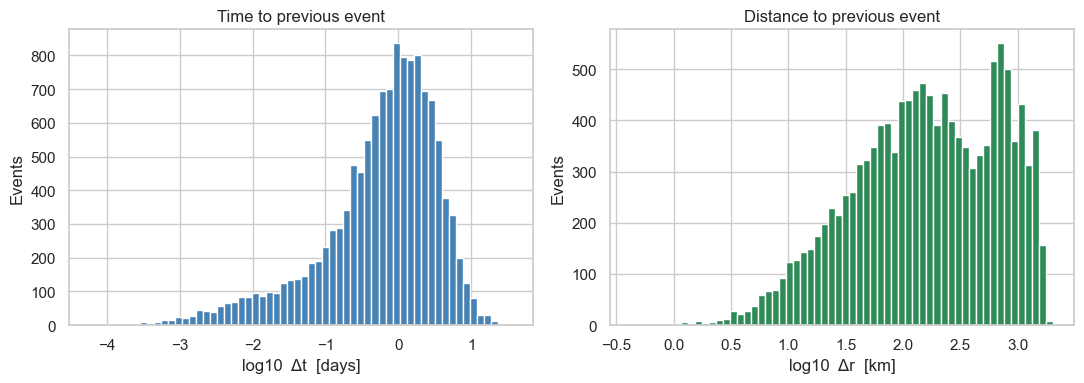

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(np.log10(dt_prev_days), bins=60, color="steelblue", edgecolor="white")
axes[0].set(xlabel="log10  Δt  [days]", ylabel="Events", title="Time to previous event")

axes[1].hist(np.log10(d_prev_km.clip(lower=1e-2)), bins=60,
             color="seagreen", edgecolor="white")
axes[1].set(xlabel="log10  Δr  [km]", ylabel="Events", title="Distance to previous event")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_gaps.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Zaliapin η — the bimodal headline feature

For each event j, the nearest-neighbour distance is

$$\eta_j = \min_i \, T_{ij} \cdot R_{ij},
  \qquad T_{ij} = (t_j - t_i)\, 10^{-qbM_i},
  \qquad R_{ij} = r_{ij}^{\,d}\, 10^{-(1-q)bM_i}$$

with the standard Zaliapin & Ben-Zion (2008) defaults: b = 1.0, d = 1.6, q = 0.5.

The expected shape is **two peaks**: a *cluster lobe* at low η (events triggered
by a recent, nearby, comparable-size parent) and a *background lobe* at high η.
The valley between them is the natural cluster/background threshold.

### 3.1 Detect the two peaks and the saddle

In [7]:
log10_eta = features["log10_eta"].dropna()
cluster_peak, background_peak, saddle, _, _ = find_bimodal_saddle(log10_eta)

print(f"Cluster peak     log10 η = {cluster_peak:.2f}")
print(f"Background peak  log10 η = {background_peak:.2f}")
print(f"Saddle (cut)     log10 η = {saddle:.2f}")

n_clustered = int((log10_eta < saddle).sum())
n_background = len(log10_eta) - n_clustered
print()
print(f"Below saddle (clustered):  {n_clustered:>5}  ({100 * n_clustered / len(log10_eta):.1f}%)")
print(f"Above saddle (background): {n_background:>5}  ({100 * n_background / len(log10_eta):.1f}%)")

Cluster peak     log10 η = -7.67
Background peak  log10 η = -4.58
Saddle (cut)     log10 η = -7.40

Below saddle (clustered):    929  (7.2%)
Above saddle (background): 11936  (92.8%)


### 3.2 Histogram with peaks and saddle marked

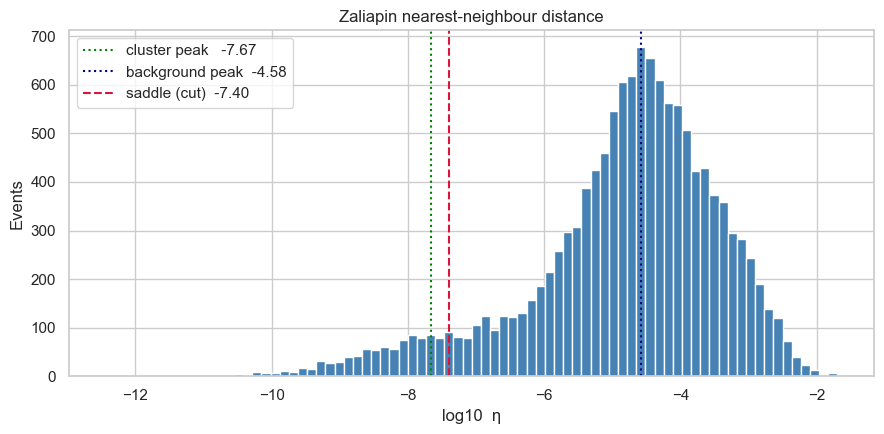

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(log10_eta, bins=80, color="steelblue", edgecolor="white")
ax.axvline(cluster_peak,    color="green",   ls=":",  label=f"cluster peak   {cluster_peak:.2f}")
ax.axvline(background_peak, color="navy",    ls=":",  label=f"background peak  {background_peak:.2f}")
ax.axvline(saddle,          color="crimson", ls="--", label=f"saddle (cut)  {saddle:.2f}")
ax.set(xlabel="log10  η", ylabel="Events",
       title="Zaliapin nearest-neighbour distance")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "02_eta_bimodal.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Two lobes in the (log T, log R) plane

In the rescaled time–distance plane, cluster events form a tight lobe at small
T and small R, while background events spread across a broad lobe at larger T
or R. A diagonal line across this plane is the standard 2-D declustering
threshold (used in clustering.py later).

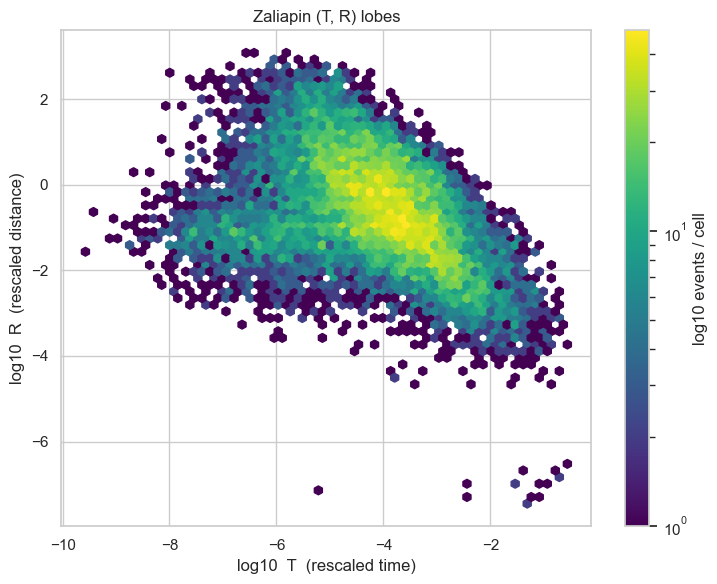

In [9]:
valid_TR = features.dropna(subset=["zaliapin_T", "zaliapin_R"])

fig, ax = plt.subplots(figsize=(7.5, 6))
hexbin = ax.hexbin(
    np.log10(valid_TR["zaliapin_T"]),
    np.log10(valid_TR["zaliapin_R"]),
    gridsize=60, cmap="viridis", mincnt=1, bins="log",
)
ax.set(
    xlabel="log10  T  (rescaled time)",
    ylabel="log10  R  (rescaled distance)",
    title="Zaliapin (T, R) lobes",
)
plt.colorbar(hexbin, ax=ax, label="log10 events / cell")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_TR_lobes.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Local activity in (50 km, 30 day) windows

Three views:

- `local_density_30d`: how many events live in the 50 km / 30 day window
  before each event.
- `bath_residual`: `max(M in window) - M - 1.2`. Båth's law predicts the
  largest aftershock is ≈ 1.2 mag below its mainshock, so a residual near 0
  is "this event behaves like the largest aftershock of a mainshock above it".
- `mag_diff_local_max`: `M - max(M in window)`. Negative means smaller than
  the local max; positive means this event is the new local max.

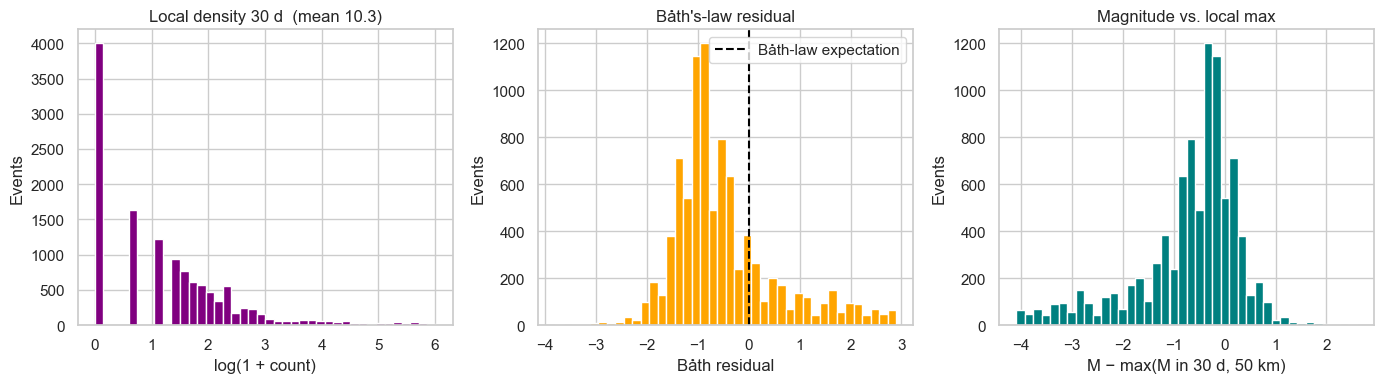

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(np.log1p(features["local_density_30d"]), bins=40,
             color="purple", edgecolor="white")
axes[0].set(xlabel="log(1 + count)", ylabel="Events",
            title=f"Local density 30 d  (mean {features['local_density_30d'].mean():.1f})")

axes[1].hist(features["bath_residual"].dropna(), bins=40,
             color="orange", edgecolor="white")
axes[1].axvline(0, color="black", ls="--", label="Båth-law expectation")
axes[1].legend()
axes[1].set(xlabel="Båth residual", ylabel="Events", title="Båth's-law residual")

axes[2].hist(features["mag_diff_local_max"].dropna(), bins=40,
             color="teal", edgecolor="white")
axes[2].set(xlabel="M − max(M in 30 d, 50 km)", ylabel="Events",
            title="Magnitude vs. local max")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_local_activity.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Case study — Kashmir M7.6, 8 October 2005

This is one of the named verification sequences in the proposal. We slice the
catalog to a 60-day window after the mainshock in the Kashmir region and
inspect how the features behave through the sequence.

### 6.1 Pull the sequence

In [11]:
kashmir = slice_to_window(
    features,
    start_time="2005-10-08", end_time="2005-12-08",
    lat_min=33.0, lat_max=36.0,
    lon_min=72.0, lon_max=75.0,
)
kashmir["days_since_main"] = (
    (kashmir["time"] - kashmir["time"].iloc[0]).dt.total_seconds() / 86_400
)
mainshock_magnitude = kashmir["mag"].max()

print(f"{len(kashmir)} events in the Kashmir 2005 window")
print(f"Mainshock magnitude: M{mainshock_magnitude:.1f}")
print(f"Båth M − 1.2 = {mainshock_magnitude - 1.2:.1f}  "
      "(expected upper bound for the largest aftershock)")

485 events in the Kashmir 2005 window
Mainshock magnitude: M7.6
Båth M − 1.2 = 6.4  (expected upper bound for the largest aftershock)


### 6.2 Magnitude vs. time — does Båth's law hold?

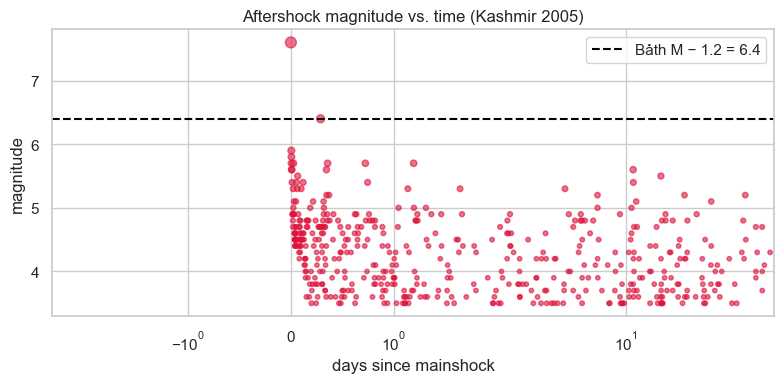

In [12]:
marker_sizes = 10 + 4 * (kashmir["mag"] - 4) ** 2

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(kashmir["days_since_main"], kashmir["mag"],
           s=marker_sizes, c="crimson", alpha=0.6)
ax.axhline(mainshock_magnitude - 1.2, color="black", ls="--",
           label=f"Båth M − 1.2 = {mainshock_magnitude - 1.2:.1f}")
ax.set(xscale="symlog",
       xlabel="days since mainshock", ylabel="magnitude",
       title="Aftershock magnitude vs. time (Kashmir 2005)")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "02_kashmir_magnitudes.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.3 Cumulative count — does Omori's law hold?

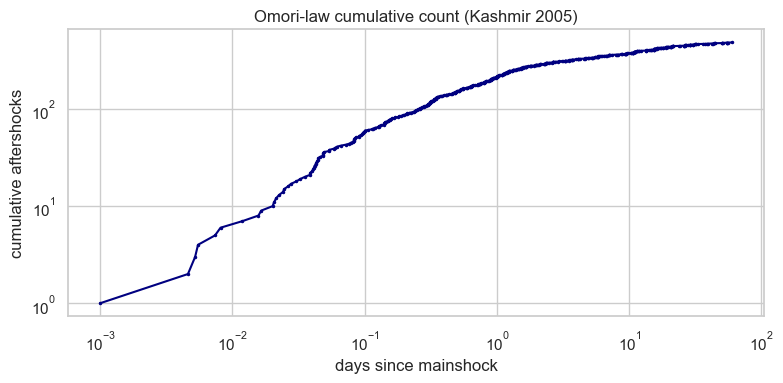

In [13]:
# Omori's law n(t) ∝ 1/t^p means cumulative count grows roughly linearly
# in log–log: a near-straight line on the plot below.
days_since_main = np.maximum(kashmir["days_since_main"], 1e-3)
cumulative_count = np.arange(1, len(kashmir) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(days_since_main, cumulative_count, color="navy", marker=".", ms=3)
ax.set(xscale="log", yscale="log",
       xlabel="days since mainshock", ylabel="cumulative aftershocks",
       title="Omori-law cumulative count (Kashmir 2005)")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_kashmir_omori.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.4 η through the sequence — should drop sharply after the mainshock

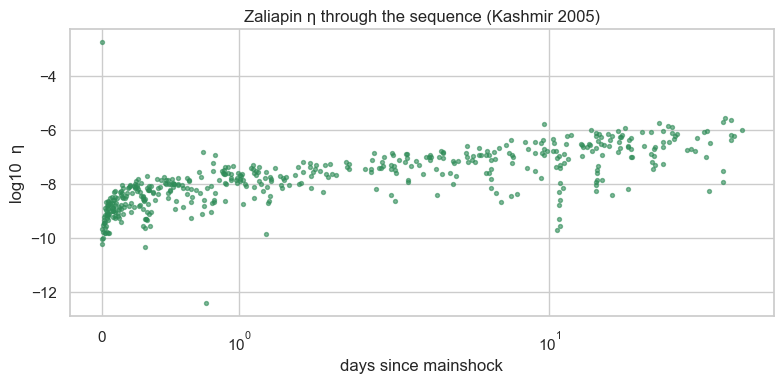

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(kashmir["days_since_main"], kashmir["log10_eta"],
           s=8, c="seagreen", alpha=0.6)
ax.set(xscale="symlog",
       xlabel="days since mainshock", ylabel="log10  η",
       title="Zaliapin η through the sequence (Kashmir 2005)")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_kashmir_eta.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Summary

- **log10 η is bimodal** with a saddle near the literature value (≈ −5 to −7),
  giving a principled threshold for declustering.
- The **(T, R) plane** shows two clear lobes — the proper 2-D Zaliapin split
  used in `src.clustering`.
- The **Kashmir 2005** sequence is recovered: rapid magnitude decay, the
  largest aftershock sits below the Båth M−1.2 line, the cumulative count
  follows Omori's law, and η drops by 6+ orders of magnitude within hours of
  the M7.6 mainshock.

These features are the inputs to `src.clustering` (DBSCAN / ST-DBSCAN) and
`src.classify` (SVM / Decision Tree / Naive Bayes / KNN) in the next stages.